In [57]:
import pandas as pd

In [58]:
df = pd.read_excel('/content/Call-Center-Sentiment-Sample-Data.xlsx',header=None)

In [59]:
df.drop(0,axis=1,inplace=True)

In [60]:
df.dropna(inplace=True)

In [61]:
df.shape

(71, 12)

In [62]:
df.reset_index(inplace=True, drop=True)

In [63]:
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df

,ID,Customer Name,Sentiment,CSAT Score,Call Timestamp,Reason,City,State,Channel,Response Time,Call Duration (Minutes),Call Center
0,PIS-39858047,Frances Gullefant,Neutral,8,2024-01-01 00:00:00,Billing Question,Charleston,West Virginia,Chatbot,Within SLA,14,Chicago/IL
1,ROH-40287216,Harcourt Zoanetti,Negative,5,2024-01-01 00:00:00,Billing Question,Honolulu,Hawaii,Call-Center,Within SLA,32,Los Angeles/CA
2,NKC-39578431,Washington Oxteby,Negative,3,2024-01-02 00:00:00,Billing Question,Dallas,Texas,Chatbot,Within SLA,6,Denver/CO
3,APY-17008648,Rafe Duffitt,Very Negative,4,2024-01-02 00:00:00,Billing Question,Fort Myers,Florida,Email,Below SLA,26,Los Angeles/CA
4,MHK-38443501,Tris Bent,Positive,8,2024-01-02 00:00:00,Billing Question,Tuscaloosa,Alabama,Web,Within SLA,26,Los Angeles/CA
...,...,...,...,...,...,...,...,...,...,...,...,...
65,JCE-87896568,Llewellyn Pablos,Very Positive,9,2024-01-29 00:00:00,Payments,Lubbock,Texas,Call-Center,Within SLA,33,Los Angeles/CA
66,GZL-83273642,Lurleen Swadden,Neutral,8,2024-01-30 00:00:00,Payments,Chicago,Illinois,Call-Center,Within SLA,8,Baltimore/MD
67,YHK-31842577,Ardith Bunting,Negative,3,2024-01-30 00:00:00,Billing Question,Columbus,Ohio,Web,Within SLA,19,Baltimore/MD
68,BGA-81071725,Wylie Gramer,Negative,3,2024-01-31 00:00:00,Billing Question,Columbus,Georgia,Web,Within SLA,23,Los Angeles/CA


In [64]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ','_',regex=True)

In [65]:
df.columns

Index(['id', 'customer_name', 'sentiment', 'csat_score', 'call_timestamp',
       'reason', 'city', 'state', 'channel', 'response_time',
       'call_duration_(minutes)', 'call_center'],
      dtype='object', name=0)

In [66]:
df['sentiment'].value_counts()

,count
sentiment,
Negative,29
Very Negative,15
Positive,10
Neutral,9
Very Positive,7


In [87]:
# merging the positive and very postive to one and similar with negative
df['sentiment'] = df['sentiment'].replace(['Very Positive'], 'Positive')
df['sentiment'] = df['sentiment'].replace(['Very Negative'], 'Negative')
y = df['sentiment']

In [76]:
X = df[['csat_score','reason', 'channel', 'response_time','call_duration_(minutes)', 'call_center']]

In [79]:
X.rename(columns={'call_duration_(minutes)':'call_duration'},inplace=True)

/tmp/ipykernel_10748/1208224688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.rename(columns={'call_duration_(minutes)':'call_duration'},inplace=True)


In [80]:
X

,csat_score,reason,channel,response_time,call_duration,call_center
0,8,Billing Question,Chatbot,Within SLA,14,Chicago/IL
1,5,Billing Question,Call-Center,Within SLA,32,Los Angeles/CA
2,3,Billing Question,Chatbot,Within SLA,6,Denver/CO
3,4,Billing Question,Email,Below SLA,26,Los Angeles/CA
4,8,Billing Question,Web,Within SLA,26,Los Angeles/CA
...,...,...,...,...,...,...
65,9,Payments,Call-Center,Within SLA,33,Los Angeles/CA
66,8,Payments,Call-Center,Within SLA,8,Baltimore/MD
67,3,Billing Question,Web,Within SLA,19,Baltimore/MD
68,3,Billing Question,Web,Within SLA,23,Los Angeles/CA


In [90]:
y

,sentiment
0,Neutral
1,Negative
2,Negative
3,Negative
4,Positive
...,...
65,Positive
66,Neutral
67,Negative
68,Negative


In [91]:
from sklearn.preprocessing import LabelEncoder ,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [92]:
trans1 = LabelEncoder()
trans2 = OneHotEncoder()
trans3 = StandardScaler()

In [114]:
ct = ColumnTransformer([
    ('trans2',trans2,['reason','channel','response_time','call_center']),
    ('trans3',trans3,['csat_score','call_duration'])
])

In [121]:
y_trans = trans1.fit_transform(y)

y_trans_df = pd.Series(y_trans)

In [115]:
X_trans = ct.fit_transform(X)

In [116]:
X_trans_df = pd.DataFrame(X_trans)

In [117]:
X_trans_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.126813,-0.981655
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.138592,0.459936
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.982195,-1.622362
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.560394,-0.020594
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.126813,-0.020594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.548614,0.540025
66,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.126813,-1.462185
67,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,-0.982195,-0.581213
68,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.982195,-0.260859


In [119]:
from sklearn.model_selection import train_test_split

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X_trans_df, y_trans_df, test_size=0.2, random_state=42)

In [124]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((56, 16), (14, 16), (56,), (14,))

In [125]:
import matplotlib.pyplot as plt

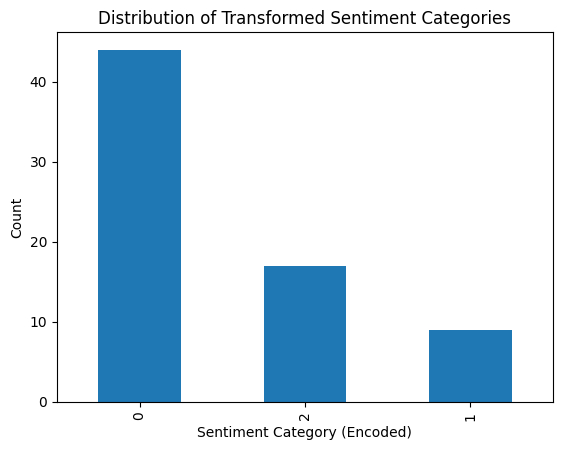

In [140]:
y_trans_df.value_counts().plot(kind='bar')
plt.title('Distribution of Transformed Sentiment Categories')
plt.xlabel('Sentiment Category (Encoded)')
plt.ylabel('Count')
plt.show()

In [157]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report , r2_score

In [128]:
rdc = RandomForestClassifier()

In [129]:
rdc.fit(X_train,y_train)

RandomForestClassifier()

In [131]:
y_pred = rdc.predict(X_test)

In [132]:
accuracy_score(y_test,y_pred)

0.9285714285714286

In [133]:
confusion_matrix(y_test,y_pred)

array([[9, 0, 0],
       [1, 1, 0],
       [0, 0, 3]])

In [135]:
report = classification_report(y_test,y_pred)

In [136]:
print(report)

              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.50      0.67         2
           2       1.00      1.00      1.00         3

    accuracy                           0.93        14
   macro avg       0.97      0.83      0.87        14
weighted avg       0.94      0.93      0.92        14



In [160]:
from sklearn.pipeline import make_pipeline

# creating pipeline
pipe = make_pipeline(ct, rdc)

In [141]:
from sklearn.neighbors import KNeighborsClassifier

In [146]:
clf= KNeighborsClassifier()

In [147]:
clf.fit(X_train,y_train)

KNeighborsClassifier()

In [149]:
y_pred = clf.predict(X_test)

In [150]:
accuracy_score(y_test,y_pred)

0.8571428571428571

In [161]:
from sklearn.linear_model import LinearRegression , Ridge , Lasso

In [152]:
lr = LinearRegression()

In [154]:
lr.fit(X_train,y_train)

LinearRegression()

In [155]:
y_pred = lr.predict(X_test)

In [159]:
r2_score(y_test,y_pred)

0.6352391895796545

In [187]:
clf2 = Ridge(alpha=6)

In [188]:
clf2.fit(X_train,y_train)

Ridge(alpha=6)

In [189]:
y_pred = clf2.predict(X_test)

In [190]:
r2_score(y_test,y_pred)

0.6563934164333229

In [199]:
clf3 = Lasso()

In [200]:
clf3.fit(X_train,y_train)

Lasso()

In [201]:
y_pred = clf3.predict(X_test)

In [202]:
r2_score(y_test,y_pred)

-0.004261363636363313